In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import sys
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import ParameterGrid

import matplotlib.pyplot as plt

sys.path.append('../..')
from nonlinear_significance.scripts.TreeTester import TreeTester

from simulations_util import *

## 1. Correlated features

In [2]:
%%capture

n = 100
d = 10
s = 5
t = 5
rho_grid = [0, 0.5, 0.8, 0.9, 0.95, 0.99]
beta = 1
sigma = 0.1
runs = 10

FI_means = []
FI_stds = []
r2f_means = []
r2f_stds = []
for rho in tqdm(rho_grid):
    Sigma = np.eye(d)
    for i in range(t):
        for j in range(i):
            Sigma[i, j] = rho
            Sigma[j, i] = rho
    FI_results = []
    r2f_results = []
    for r in range(runs):
        X = np.random.multivariate_normal(np.zeros(d), Sigma, size=n)
        y = linear_model(X, sigma, s, beta)
        rf_model = RandomForestRegressor(max_features=0.33)
        rf_model.fit(X, y)
        FI_results.append(rf_model.feature_importances_)
        tree_tester = TreeTester(rf_model)
        r2f_results.append(tree_tester.get_r_squared_sig_threshold(X, y))
    FI_results = np.array(FI_results)
    r2f_results = np.array(r2f_results)
    FI_means.append(np.mean(FI_results, axis=0))
    FI_stds.append(np.std(FI_results, axis=0))
    r2f_means.append(np.mean(r2f_results, axis=0))
    r2f_stds.append(np.std(r2f_results, axis=0))
FI_means = pd.DataFrame(FI_means)
FI_stds = pd.DataFrame(FI_stds)
r2f_means = pd.DataFrame(r2f_means)
r2f_stds = pd.DataFrame(r2f_stds)

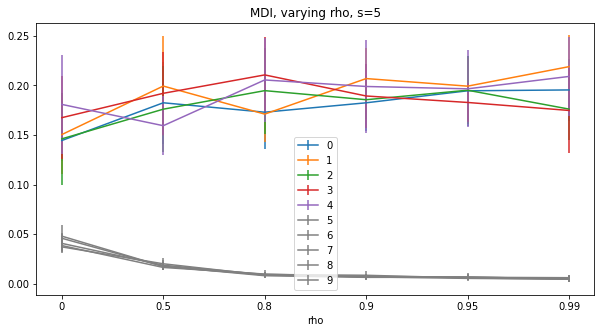

In [3]:
plt.figure(figsize=(10, 5))
for i in range(t):
    plt.errorbar(range(len(rho_grid)), FI_means.iloc[:,i], yerr=FI_stds[i], label=i)
for i in range(t, d):
    plt.errorbar(range(len(rho_grid)), FI_means.iloc[:,i], yerr=FI_stds[i], label=i, color="gray")
plt.legend()
plt.xticks(ticks=range(len(rho_grid)), labels=rho_grid)
plt.xlabel("rho")
plt.title("MDI, varying rho, s=5")
plt.show()

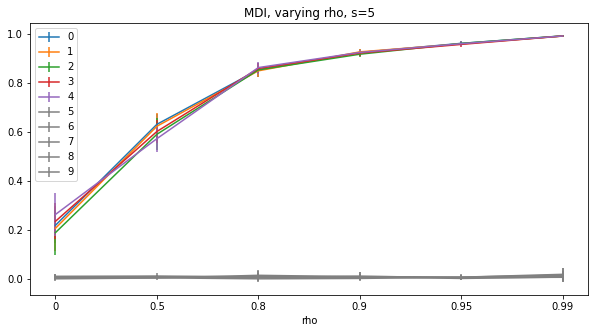

In [4]:
plt.figure(figsize=(10, 5))
for i in range(t):
    plt.errorbar(range(len(rho_grid)), r2f_means.iloc[:,i], yerr=r2f_stds[i], label=i)
for i in range(t, d):
    plt.errorbar(range(len(rho_grid)), r2f_means.iloc[:,i], yerr=r2f_stds[i], label=i, color="gray")
plt.legend()
plt.xticks(ticks=range(len(rho_grid)), labels=rho_grid)
plt.xlabel("rho")
plt.title("MDI, varying rho, s=5")
plt.show()

In [5]:
%%capture

n = 100
d = 10
s = 1
t = 5
rho_grid = [0, 0.5, 0.8, 0.9, 0.95, 0.99]
beta = 1
sigma = 0.1
runs = 10

FI_means = []
FI_stds = []
r2f_means = []
r2f_stds = []
for rho in tqdm(rho_grid):
    Sigma = np.eye(d)
    for i in range(t):
        for j in range(i):
            Sigma[i, j] = rho
            Sigma[j, i] = rho
    FI_results = []
    r2f_results = []
    for r in range(runs):
        X = np.random.multivariate_normal(np.zeros(d), Sigma, size=n)
        y = linear_model(X, sigma, s, beta)
        rf_model = RandomForestRegressor(max_features=0.33)
        rf_model.fit(X, y)
        FI_results.append(rf_model.feature_importances_)
        tree_tester = TreeTester(rf_model)
        r2f_results.append(tree_tester.get_r_squared_sig_threshold(X, y))
    FI_results = np.array(FI_results)
    r2f_results = np.array(r2f_results)
    FI_means.append(np.mean(FI_results, axis=0))
    FI_stds.append(np.std(FI_results, axis=0))
    r2f_means.append(np.mean(r2f_results, axis=0))
    r2f_stds.append(np.std(r2f_results, axis=0))
FI_means = pd.DataFrame(FI_means)
FI_stds = pd.DataFrame(FI_stds)
r2f_means = pd.DataFrame(r2f_means)
r2f_stds = pd.DataFrame(r2f_stds)

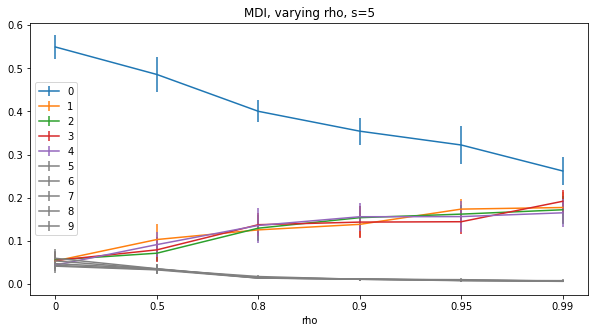

In [6]:
plt.figure(figsize=(10, 5))
for i in range(t):
    plt.errorbar(range(len(rho_grid)), FI_means.iloc[:,i], yerr=FI_stds[i], label=i)
for i in range(t, d):
    plt.errorbar(range(len(rho_grid)), FI_means.iloc[:,i], yerr=FI_stds[i], label=i, color="gray")
plt.legend()
plt.xticks(ticks=range(len(rho_grid)), labels=rho_grid)
plt.xlabel("rho")
plt.title("MDI, varying rho, s=5")
plt.show()

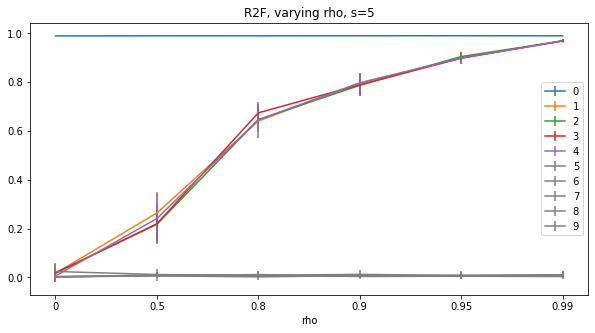

In [7]:
plt.figure(figsize=(10, 5))
for i in range(t):
    plt.errorbar(range(len(rho_grid)), r2f_means.iloc[:,i], yerr=r2f_stds[i], label=i)
for i in range(t, d):
    plt.errorbar(range(len(rho_grid)), r2f_means.iloc[:,i], yerr=r2f_stds[i], label=i, color="gray")
plt.legend()
plt.xticks(ticks=range(len(rho_grid)), labels=rho_grid)
plt.xlabel("rho")
plt.title("R2F, varying rho, s=5")
plt.show()

# Temp

In [8]:
r2f_means

,0,1,2,3,4,5,6,7,8,9
0,0.989693,0.016293,0.018713,0.016854,0.005495,0.023866,0.003014,0.000910,0.002533,0.001781
1,0.990090,0.263795,0.217265,0.219647,0.240991,0.011527,0.005991,0.009137,0.009377,0.005649
2,0.990038,0.640606,0.646883,0.674327,0.645565,0.005153,0.011319,0.009425,0.008229,0.001776
3,0.990279,0.797084,0.786881,0.789605,0.797143,0.007715,0.004550,0.003410,0.012193,0.006847
4,0.990492,0.898972,0.905057,0.898131,0.898851,0.003709,0.006798,0.004448,0.007145,0.008595
5,0.989959,0.968612,0.968932,0.969895,0.969672,0.010855,0.004286,0.003096,0.010039,0.009024


In [9]:
import statsmodels.api as sm

In [10]:
X = np.random.multivariate_normal(np.zeros(d), Sigma, size=n)
y = linear_model(X, sigma, s, beta)
OLS_results = sm.OLS(y, X).fit(cov_type="HC0")

In [11]:
rf_model = RandomForestRegressor(max_features=0.33)
rf_model.fit(X, y)
tree_tester = TreeTester(rf_model)
tree_tester.get_r_squared_sig_threshold(X, y)

  0%|          | 0/10 [00:00<?, ?it/s]/Users/yanshuotan/anaconda3/lib/python3.7/site-packages/statsmodels/regression/linear_model.py:2169: InvalidTestWarning: F test for comparison is likely invalid with robust covariance, proceeding anyway
  InvalidTestWarning)
/Users/yanshuotan/anaconda3/lib/python3.7/site-packages/statsmodels/regression/linear_model.py:2169: InvalidTestWarning: F test for comparison is likely invalid with robust covariance, proceeding anyway
  InvalidTestWarning)
/Users/yanshuotan/anaconda3/lib/python3.7/site-packages/statsmodels/regression/linear_model.py:2169: InvalidTestWarning: F test for comparison is likely invalid with robust covariance, proceeding anyway
  InvalidTestWarning)
/Users/yanshuotan/anaconda3/lib/python3.7/site-packages/statsmodels/regression/linear_model.py:2169: InvalidTestWarning: F test for comparison is likely invalid with robust covariance, proceeding anyway
  InvalidTestWarning)
/Users/yanshuotan/anaconda3/lib/python3.7/site-packages/statsm

array([0.98677796, 0.97075065, 0.96729734, 0.96414898, 0.96681471,
       0.00985322, 0.        , 0.        , 0.        , 0.        ])

In [26]:
OLS_results.rsquared

0.9906710228632398

In [46]:
p_values = np.zeros(d)
OLS_full = sm.OLS(y, X[:,0]).fit()
p_values[0] = OLS_full.f_pvalue
for i in range(1, d):
    OLS_restricted = OLS_full
    OLS_full = sm.OLS(y, X[:, np.arange(i+1)]).fit(cov_type="HC0")
    p_values[i] = OLS_full.compare_f_test(OLS_restricted)[1]

/Users/yanshuotan/anaconda3/lib/python3.7/site-packages/statsmodels/regression/linear_model.py:2169: InvalidTestWarning: F test for comparison is likely invalid with robust covariance, proceeding anyway
  InvalidTestWarning)
/Users/yanshuotan/anaconda3/lib/python3.7/site-packages/statsmodels/regression/linear_model.py:2169: InvalidTestWarning: F test for comparison is likely invalid with robust covariance, proceeding anyway
  InvalidTestWarning)
/Users/yanshuotan/anaconda3/lib/python3.7/site-packages/statsmodels/regression/linear_model.py:2169: InvalidTestWarning: F test for comparison is likely invalid with robust covariance, proceeding anyway
  InvalidTestWarning)
/Users/yanshuotan/anaconda3/lib/python3.7/site-packages/statsmodels/regression/linear_model.py:2169: InvalidTestWarning: F test for comparison is likely invalid with robust covariance, proceeding anyway
  InvalidTestWarning)
/Users/yanshuotan/anaconda3/lib/python3.7/site-packages/statsmodels/regression/linear_model.py:2169:

In [47]:
p_values

array([1.06529759e-08, 1.36904701e-08, 3.56131196e-09, 2.40096796e-19,
       3.26383207e-89, 9.93559410e-01, 5.96610470e-01, 2.47511865e-01,
       6.89876141e-01, 1.16475755e-01])

In [17]:
results = sm.OLS(y, X[:,0]).fit()

In [49]:
np.nonzero([False, False, False])[0]

array([], dtype=int64)